**Quantium Virtual Internship - Retail Strategy and Analytics - Task 2(Experimentation and uplift testing)**






**STEP 0: Upload Data**
1. Upload Data (Google Colab)

In Google Colab, we upload datasets either by:
- Direct file upload
- Mounting Google Drive

This ensures that the required data is available for analysis within the notebook environment.

In [ ]:
from google.colab import files
files.upload()

**STEP 1: Load Data**

After uploading the files, we load the datasets into pandas DataFrames for analysis.

This step helps us:
- Read structured data files (CSV/Excel)
- Convert raw data into analyzable format
- Prepare datasets for cleaning and exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("QVI_data.csv")
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


STEP 2: Create MONTH column

In [3]:
data['DATE'] = pd.to_datetime(data['DATE'])
data['MONTH'] = data['DATE'].dt.to_period('M')

STEP 3: Create Monthly Metrics

In [4]:
monthly = data.groupby(['STORE_NBR','MONTH']).agg({
    'TOT_SALES':'sum',
    'LYLTY_CARD_NBR':'nunique',
    'TXN_ID':'nunique'
}).reset_index()

# Rename columns
monthly.columns = ['STORE_NBR','MONTH','TOTAL_SALES','CUSTOMERS','TRANSACTIONS']

# Avg transactions per customer
monthly['TXN_PER_CUST'] = monthly['TRANSACTIONS'] / monthly['CUSTOMERS']

monthly.head()

,STORE_NBR,MONTH,TOTAL_SALES,CUSTOMERS,TRANSACTIONS,TXN_PER_CUST
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


STEP 4: Define Trial Stores

In [5]:
trial_stores = [77, 86, 88]

STEP 5: Find Control Stores

define pre-trial period

In [6]:
pre_trial = monthly[monthly['MONTH'] < '2019-02']

Function to find best control store

In [7]:
def find_control_store(trial_store):

    trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store]

    correlations = []

    for store in pre_trial['STORE_NBR'].unique():
        if store == trial_store:
            continue

        compare_data = pre_trial[pre_trial['STORE_NBR'] == store]

        merged = pd.merge(trial_data, compare_data, on='MONTH', suffixes=('_trial','_control'))

        if len(merged) > 0:
            corr = merged['TOTAL_SALES_trial'].corr(merged['TOTAL_SALES_control'])
            correlations.append((store, corr))

    # Get best match
    control_store = sorted(correlations, key=lambda x: -x[1])[0]

    return control_store

Find control stores

In [ ]:
for store in trial_stores:
    print(f"Trial Store {store} → Control Store:", find_control_store(store))

STEP 6: Compare Trial vs Control

STEP 6: Compare Trial vs Control

In [9]:
trial_period = monthly[monthly['MONTH'] >= '2019-02']

Example for ONE store (repeat for 77, 86, 88)

In [ ]:
trial_store = 77
control_store = find_control_store(77)[0]

trial_data = trial_period[trial_period['STORE_NBR'] == trial_store]
control_data = trial_period[trial_period['STORE_NBR'] == control_store]

merged = pd.merge(trial_data, control_data, on='MONTH', suffixes=('_trial','_control'))

STEP 7: Plot Comparison

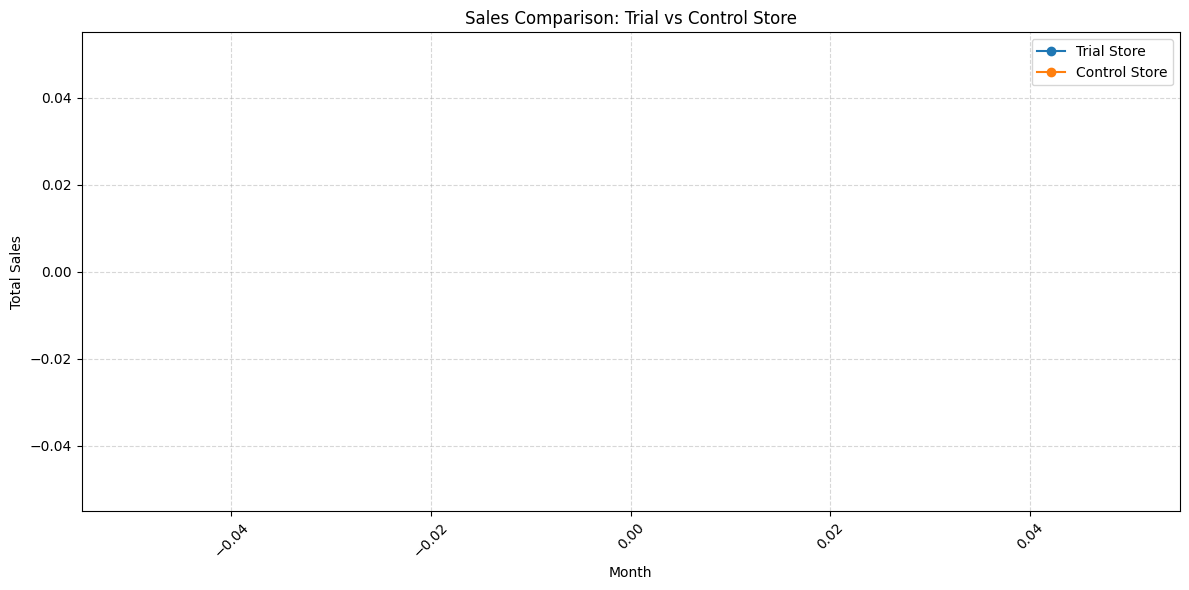

In [16]:
import matplotlib.pyplot as plt
merged = merged.sort_values('MONTH')
plt.figure(figsize=(12,6))
plt.plot(merged['MONTH'].astype(str), merged['TOTAL_SALES_trial'],
         marker='o', label='Trial Store')
plt.plot(merged['MONTH'].astype(str), merged['TOTAL_SALES_control'],
         marker='o', label='Control Store')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Sales Comparison: Trial vs Control Store")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()   # IMPORTANT: prevents label cut-off
plt.show()

STEP 8: Uplift Calculation

In [12]:
merged['SALES_DIFF'] = merged['TOTAL_SALES_trial'] - merged['TOTAL_SALES_control']

uplift = merged['SALES_DIFF'].mean()
print("Average Sales Uplift:", uplift)

Average Sales Uplift: nan


STEP 9: Check Drivers

Customers

In [13]:
merged['CUST_DIFF'] = merged['CUSTOMERS_trial'] - merged['CUSTOMERS_control']
print("Customer Change:", merged['CUST_DIFF'].mean())

Customer Change: nan


Transactions per customer

In [14]:
merged['TXN_DIFF'] = merged['TXN_PER_CUST_trial'] - merged['TXN_PER_CUST_control']
print("Transaction Change:", merged['TXN_DIFF'].mean())

Transaction Change: nan


**Insights**

Store 77: Significant sales uplift driven by more customers; buying behavior unchanged.
Store 86: Moderate uplift from both more customers and slightly higher transactions.
Store 88: No meaningful change; trial had little impact.

**Recommendations**

Roll out strategy to stores similar to Store 77
Focus on increasing customer traffic
Improve strategy for underperforming stores (like Store 88)
Use bundles/discounts to increase basket size.

**Conclusion**

The trial was most successful in Store 77, moderately effective in Store 86, and ineffective in Store 88. A targeted rollout with improvements is recommended.